
We need to predict whether a customer will leave the bank soon.Build a model with the maximum possible F1 score. To pass the project, you need an F1 score of at least 0.59. Check the F1 for the test set.
Additionally, measure the AUC-ROC metric and compare it with the F1.

In [28]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve


Imported all libraries needed


In [29]:
df = pd.read_csv('/datasets/Churn.csv')

display(df.info())
display(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


None

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Load and check data


In [30]:
irrelevant = pd.Series(['RowNumber', 'CustomerId', 'Surname'])
new_df = df.drop(irrelevant, axis=1)

print('Total Duplicates in new_df :', new_df.duplicated().sum())

Total Duplicates in new_df : 0



creating new df dropping irrelevant features for testing and checking for duplicates in new_df. then split into features and target.


In [31]:
new_df = new_df.fillna(new_df['Tenure'].median())
print(new_df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [32]:
gender_dict = {'Male': 1, 'Female': 0}
new_df['Gender'] = new_df['Gender'].map(gender_dict)


create dictionary of values for gender since there are only 2 


In [33]:
ohe = pd.get_dummies(new_df['Geography'], drop_first=True)

print(ohe)

new_df = new_df.drop('Geography', axis=1) 
new_df = pd.concat([new_df, ohe], axis=1)

      Germany  Spain
0           0      0
1           0      1
2           0      0
3           0      0
4           0      1
...       ...    ...
9995        0      0
9996        0      0
9997        0      0
9998        1      0
9999        0      0

[10000 rows x 2 columns]



using OHE to apply values to countries since there are more than 2

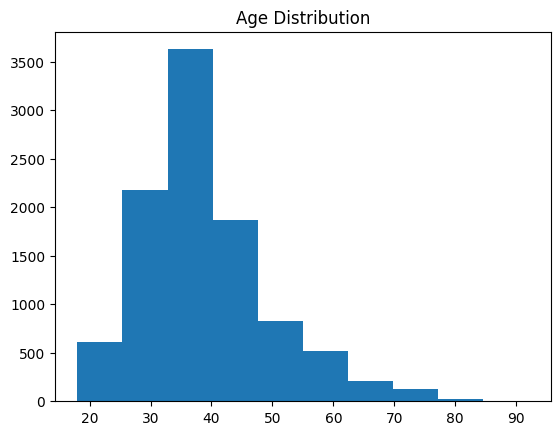

In [34]:
plt.hist(new_df['Age'])
plt.title('Age Distribution')
plt.show()


This chart shows most of the customers are between the ages of 30-50 with a few customers under the age of 20 as well as some over the age of 70

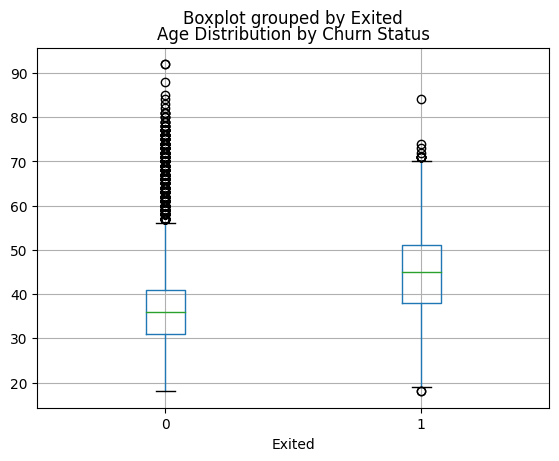

In [35]:
new_df.boxplot(column='Age', by='Exited')
plt.title('Age Distribution by Churn Status')
plt.show()

from this plot we can see that the correlation the majority of the customers who have stayed are between 31 and 41 with some outliers between the ages of 56 - 90+. While those that have exited are mainly between 38 and 51 with an outlier under 20 and a few more 70+. it does not seem age has a strong correlations with churn rate.

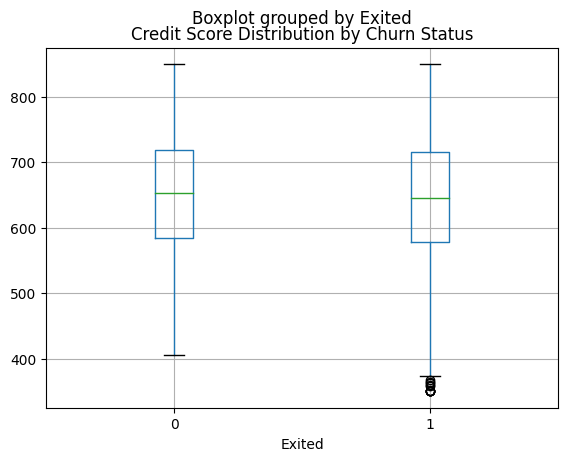

In [36]:
new_df.boxplot(column='CreditScore', by='Exited')
plt.title('Credit Score Distribution by Churn Status')
plt.show()


from this plot we can see that the customers Credit Score and wether they stay or leave has no correlation. and disributions is fairly even in the customers who stayed. There were a few outliers below 400 for those that exited. This may have an effect on the churn rate.

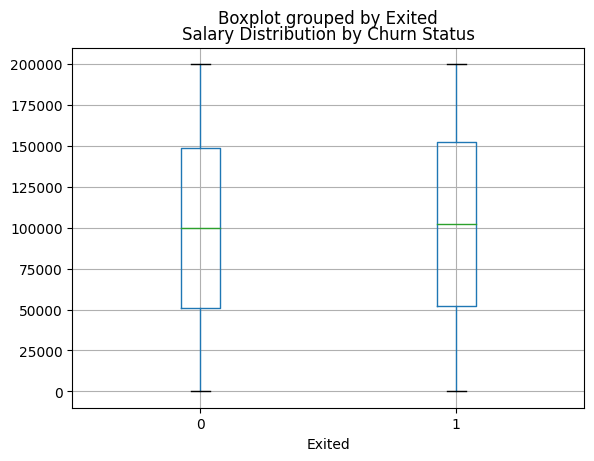

In [37]:
new_df.boxplot(column='EstimatedSalary', by='Exited')
plt.title('Salary Distribution by Churn Status')
plt.show()



from this plot we can see that the correlation between someones salary and wether they stay or leave has anything to do with it and disributions is even between both.

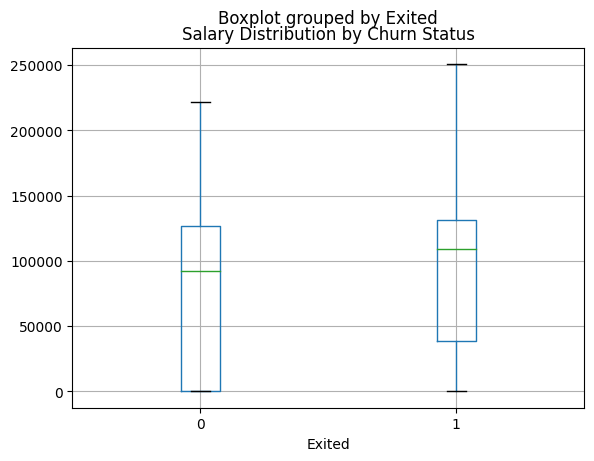

In [38]:
new_df.boxplot(column='Balance', by='Exited')
plt.title('Salary Distribution by Churn Status')
plt.show()


The majority of customers that have stayed have a balance between 0 and 130,000 with the mean being around 90,000. Those that have exited had a higher balance between 40,000 and 135,000 with the mean being around 110,000. There may be a correlation between a customers account balance and wether they stay.

In [39]:
features = new_df.drop(['Exited'], axis=1)
target = new_df['Exited']

display(features.head(5))
display(target.head(5))

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain
0,619,0,42,2.0,0.00,1,1,1,101348.88,0,0
1,608,0,41,1.0,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8.0,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1.0,0.00,2,0,0,93826.63,0,0
4,850,0,43,2.0,125510.82,1,1,1,79084.10,0,1


0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

sort the data in the new_df into features and target

In [40]:
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=12345)

created training, validation and testing sets with 60% for train, 20% for validation and 20% for testing

In [41]:
print(target_train.value_counts(normalize=True))


0    0.800667
1    0.199333
Name: Exited, dtype: float64


checking class balance. Nearly 20% have exited.

In [42]:

features_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

scaler = StandardScaler()
features_train_scaled = features_train.copy()
features_valid_scaled = features_valid.copy()

features_train_scaled[features_to_scale] = scaler.fit_transform(features_train[features_to_scale])
features_valid_scaled[features_to_scale] = scaler.transform(features_valid[features_to_scale])



Scaling data for linear regression

In [43]:

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_train_scaled, target_train)
predictions = model.predict(features_valid_scaled)
f1 = f1_score(target_valid, predictions)
print(f1)


0.33108108108108103


linear regression model is far below minimum requirements even after scaling data.

In [44]:
best_model = None
best_f1 = 0

for depth in range(1,11):
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    f1 = f1_score(target_valid, predictions)
    print(f"Depth {depth}: F1 = {f1:.4f}")

    probabilities = model.predict_proba(features_valid)[:, 1]
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    for threshold in thresholds: 
        predictions = (probabilities >= threshold).astype(int)
        f1 = f1_score(target_valid, predictions)
    
        if f1 > best_f1:
            best_model = model
            best_f1 = f1

print(f"\nBest model: max_depth = {best_model.max_depth}")
print(f"Best F1 score: {best_f1:.4f}")
print(f"Threshold {threshold}: F1 = {f1:.3f}") 

Depth 1: F1 = 0.0000
Depth 2: F1 = 0.5217
Depth 3: F1 = 0.4235
Depth 4: F1 = 0.5529
Depth 5: F1 = 0.5406
Depth 6: F1 = 0.5693
Depth 7: F1 = 0.5418
Depth 8: F1 = 0.5441
Depth 9: F1 = 0.5590
Depth 10: F1 = 0.5403

Best model: max_depth = 6
Best F1 score: 0.5995
Threshold 0.7: F1 = 0.510


Decision tree classifier is close to requirements but does not meet them.

In [45]:

best_depth = 0
best_f1 = 0
best_est = 0


for est in range(10, 101, 10):
    for depth in range(1,51):
        model = RandomForestClassifier(random_state=12345, n_estimators=est, 
        max_depth=depth, class_weight="balanced")
        model.fit(features_train, target_train)
        predictions = model.predict(features_valid)
        f1 = f1_score(target_valid, predictions)
        
    
        if f1 > best_f1:
            best_f1 = f1
            best_est = est
            best_depth = depth

print(f"\nBest model: max_depth = {best_depth}")
print(f"Best model: n_estimators = {best_est}")
print(f"Best F1 score = {best_f1:.4f}") 



Best model: max_depth = 8
Best model: n_estimators = 40
Best F1 score = 0.6394



Used class_weight='balanced' for more accurate score to find the best model. It has the most accurate score and meets the requirements for the project.

In [46]:
majority_class = features_train[target_train == 0]
minority_class = features_train[target_train == 1]

minority_upsampled = minority_class.sample(n=len(majority_class), replace=True, random_state=12345)

features_upsampled = pd.concat([majority_class, minority_upsampled])
target_upsampled = pd.concat([target_train[target_train == 0], 
                             pd.Series([1] * len(minority_upsampled))])

features_upsampled = features_upsampled.reset_index(drop=True)
target_upsampled = target_upsampled.reset_index(drop=True)


print(f"Original training set size: {len(features_train)}")
print(f"Upsampled training set size: {len(features_upsampled)}")
print(f"Class distribution in upsampled data:")
print(target_upsampled.value_counts(normalize=True))


Original training set size: 6000
Upsampled training set size: 9608
Class distribution in upsampled data:
0    0.5
1    0.5
dtype: float64


to compare upsampling for class imbalance vs class_weight. Need to create classes and upsample the minority then compine with majority and reset the index to avoid any issues.

In [47]:

best_depth = 0
best_est = 0
best_f1_upsampled = 0

for est in range(10, 101, 10):  
    for depth in range(1, 51):
        model_upsampled = RandomForestClassifier(
        random_state=12345, 
        n_estimators=est, 
        max_depth=depth)

        model_upsampled.fit(features_upsampled, target_upsampled)
        predictions_upsampled = model_upsampled.predict(features_valid)
        f1_upsampled = f1_score(target_valid, predictions_upsampled)

        if f1_upsampled > best_f1_upsampled:
            best_f1_upsampled = f1_upsampled
            best_est = est
            best_depth = depth

print(f"F1 score with upsampling: {best_f1_upsampled:.4f}")
print(f"F1 score with class_weight='balanced': {best_f1:.4f}") 
print(f"n_estimators = {best_est}")
print(f"max_depth = {best_depth}")


F1 score with upsampling: 0.6334
F1 score with class_weight='balanced': 0.6394
n_estimators = 90
max_depth = 13


tested upsampling against threshold and class_weight='blananced'. While it still preformed better than the requirement, class_weight='balanced' preformed better. 

Final f1 score = 0.6108695652173913
Final auc_roc score = 0.8542598913758805


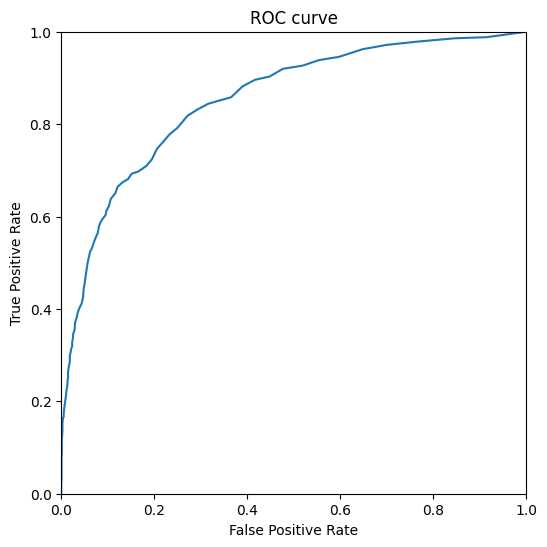

In [48]:
final_model = RandomForestClassifier(random_state=12345, n_estimators=40, 
max_depth=8, class_weight='balanced')
final_model.fit(features_train, target_train)
predictions = final_model.predict(features_test)
f1 = f1_score(target_test, predictions)
print('Final f1 score =', f1)

auc_roc = final_model.predict_proba(features_test)
probability_1_test = auc_roc[:, 1]
probability_0_test = auc_roc[:, 0]
final_auc_roc = roc_auc_score(target_test, probability_1_test)
print('Final auc_roc score =', final_auc_roc)


probabilities_final = model.predict_proba(features_test)
probabilities_1_final = probabilities_final[:, 1]

fpr, tpr, thresholds = roc_curve(target_test, probabilities_1_final)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linestyle='-')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.ylim([0.0, 1.0])
plt.xlim([0.0, 1.0])
plt.title('ROC curve')
plt.show()

The best model was the randomforestclassifier with an f1_score of 0.639 with class_weight='balanced'.  The RandomForestClassifier combines predictions from multiple decision trees, reducing the variance and improving accuracy. I used it as the final model to run against the test set as well as get the auc_roc score. F1_score preformed better than the trainging model and auc_roc Score ranks customers by churn probability effectively. For the churn rate comparisons and distributions the company may want to look further into if age or credit score is a larger factor in churn rate. with the credit score there were far more outliers sub 400's and with age the majority of the customers left between 38 and 51. Customer based incentives may help with retention for age and bank balance as well.

